# Diálise no SUS: o caminho do paciente renal

**Pergunta que este notebook responde:** quem faz diálise no meu estado, quanto
essas pessoas se deslocam para se tratar, quem oferece o serviço e o que
acontece com elas ao longo de um ano?

**Fonte:** SIA/SUS, arquivos de APAC. É **dado individual**: uma linha por
autorização, com identificador do paciente, exames laboratoriais e desfecho.
**Tempo estimado:** 6 a 12 minutos.

> Este é o único exemplo do repositório com dado clínico no nível da pessoa. O
> SIA que você conhece dos outros notebooks (o grupo `PA`) é produção agregada;
> aqui cada linha é uma pessoa autorizada a fazer diálise naquele mês.

## Preparação

In [2]:
%pip install pysus nest_asyncio -q
import nest_asyncio
nest_asyncio.apply()
print("Ambiente pronto.")

Note: you may need to restart the kernel to use updated packages.
Ambiente pronto.


## Parâmetros

In [3]:
UF = "PR"     # sigla do estado
ANO = 2024

## Passo 1 — O SIA tem catorze tipos de arquivo, não um

Quase todo mundo conhece o `PA` (produção ambulatorial). Mas o SIA publica
catorze famílias de arquivo, e é nelas que está o dado individual:

| Prefixo | O que é |
|---|---|
| `PA` | produção ambulatorial (agregada) |
| `BI` | boletim de produção individualizado |
| `AB` / `ABO` | acompanhamento de cirurgia bariátrica / pós-bariátrica |
| `ACF` | confecção de fístula arteriovenosa |
| `AD` | laudos diversos |
| `AM` / `AMP` | medicamentos / acompanhamento multiprofissional |
| `AN` | nefrologia |
| `AQ` / `AR` | quimioterapia / radioterapia |
| `ATD` | **tratamento dialítico** |
| `PS` | psicossocial |
| `SAD` | atenção domiciliar |

**A PySUS agrupa alguns desses prefixos sob nomes mais genéricos** — e alguns
desses nomes não descrevem o conteúdo. O grupo que ela chama de "Atenção
Básica" é o acompanhamento de cirurgia bariátrica; o que ela chama de "Atenção"
é o tratamento dialítico.

Confira sempre pelo procedimento, nunca pelo rótulo. O código do SIGTAP é
estruturado: dois primeiros dígitos = grupo (03 clínico, 04 cirúrgico), quatro
primeiros = subgrupo (0305 nefrologia e diálise).

In [4]:
import duckdb
import pandas as pd
from pysus import sia

def identificar(grupo, mes=1):
    caminhos = sia(state=UF, year=ANO, month=mes, group=grupo)
    if not caminhos:
        return None
    arquivos = [str(p) for p in caminhos]
    colunas = duckdb.sql(f"SELECT * FROM read_parquet({arquivos!r}) LIMIT 0").df().columns
    coluna = "AP_PRIPAL" if "AP_PRIPAL" in colunas else "PA_PROC_ID"
    d = duckdb.sql(f"""
        SELECT substr(CAST({coluna} AS VARCHAR), 1, 4) AS subgrupo, COUNT(*) AS linhas
        FROM read_parquet({arquivos!r}) GROUP BY 1 ORDER BY 2 DESC LIMIT 1
    """).df()
    return {"group= da PySUS": grupo,
            "arquivos devolvidos": ", ".join(a.split("\\")[-1].split(".")[0]
                                             for a in arquivos),
            "subgrupo SIGTAP": d.subgrupo[0], "linhas": int(d.linhas[0])}

pd.DataFrame([r for r in (identificar(g) for g in ("AT", "AB", "AM")) if r])

,group= da PySUS,arquivos devolvidos,subgrupo SIGTAP,linhas
0,AT,ATDPR2401,0305,6813
1,AB,ABOPR2401,0301,615
2,AM,"AMPR2401, AMPPR2401",0604,311217


Repare na coluna do meio: **`group="AM"` devolveu dois arquivos**, `AMPR2401` e
`AMPPR2401`. São coisas diferentes — medicamentos e acompanhamento
multiprofissional — e depois de concatenados nada no DataFrame diz de qual
arquivo veio cada linha.

Por isso este notebook não filtra pelo `group`: ele escolhe **pelo prefixo do
nome do arquivo**, que é o código original do DATASUS.

In [5]:
GRUPO_DA_PYSUS = {"ATD": "AT", "ACF": "AC", "ABO": "AB", "AB": "AB",
                  "AMP": "AM", "AM": "AM", "SAD": "SA", "PS": "PS",
                  "PA": "PA", "BI": "BI", "AD": "AD", "AN": "AN",
                  "AQ": "AQ", "AR": "AR"}

def arquivos_do_prefixo(prefixo, uf, ano, mes):
    """Só os arquivos cujo nome começa com o prefixo original do DATASUS."""
    caminhos = sia(state=uf, year=ano, month=mes, group=GRUPO_DA_PYSUS[prefixo])
    escolhidos = []
    for p in caminhos:
        nome = str(p).split("\\")[-1].split("/")[-1].split(".")[0].upper()
        letras = "".join(c for c in nome if c.isalpha())
        if letras[:-2] == prefixo:          # o fim são as duas letras da UF
            escolhidos.append(str(p))
    return escolhidos

for prefixo in ("AM", "AMP", "ATD"):
    r = arquivos_do_prefixo(prefixo, UF, ANO, 1)
    print(f"  {prefixo:4s} -> {[x.split(chr(92))[-1] for x in r]}")

AM   -> ['AMPR2401.parquet']


AMP  -> ['AMPPR2401.parquet']


ATD  -> ['ATDPR2401.parquet']


## Passo 2 — O caminho do paciente renal, em três arquivos

Os três se encaixam: para fazer hemodiálise é preciso um acesso vascular
(`ACF`), o tratamento em si é o `ATD`, e o acompanhamento da equipe é o `AMP` —
que tem as mesmas colunas clínicas do `ATD`.

In [6]:
caminho = []
for prefixo, descricao in (("ACF", "confecção de fístula"),
                           ("ATD", "tratamento dialítico"),
                           ("AMP", "acompanhamento multiprofissional")):
    arqs = arquivos_do_prefixo(prefixo, UF, ANO, 1)
    if not arqs:
        caminho.append({"prefixo": prefixo, "o que é": descricao,
                        "APACs no mês": 0, "pacientes": 0})
        continue
    d = duckdb.sql(f"""
        SELECT COUNT(*) AS apacs, COUNT(DISTINCT AP_CNSPCN) AS pacientes
        FROM read_parquet({arqs!r})
    """).df()
    caminho.append({"prefixo": prefixo, "o que é": descricao,
                    "APACs no mês": int(d.apacs[0]),
                    "pacientes": int(d.pacientes[0])})

pd.DataFrame(caminho)

,prefixo,o que é,APACs no mês,pacientes
0,ACF,confecção de fístula,125,125
1,ATD,tratamento dialítico,6813,6669
2,AMP,acompanhamento multiprofissional,143,143


## Passo 3 — Baixar o ano inteiro de diálise

Os arquivos são pequenos (alguns milhares de linhas por mês), então dá para
trazer os doze meses e seguir a mesma pessoa ao longo do tempo.

In [7]:
arquivos = []
meses = []
for mes in range(1, 13):
    achados = arquivos_do_prefixo("ATD", UF, ANO, mes)
    if achados:
        arquivos += achados
        meses.append(mes)
print(f"Meses encontrados: {meses}")

resumo = duckdb.sql(f"""
    SELECT COUNT(*) AS apacs,
           COUNT(DISTINCT AP_CNSPCN) AS pacientes,
           COUNT(DISTINCT AP_CODUNI) AS estabelecimentos,
           COUNT(DISTINCT AP_MUNPCN) AS municipios_de_residencia,
           SUM(TRY_CAST(AP_VL_AP AS DOUBLE)) AS valor
    FROM read_parquet({arquivos!r})
""").df()
print(f"\n{UF}, {ANO}:")
print(f"  {int(resumo.apacs[0]):,} autorizações")
print(f"  {int(resumo.pacientes[0]):,} pacientes distintos")
print(f"  {int(resumo.estabelecimentos[0])} estabelecimentos")
print(f"  {int(resumo.municipios_de_residencia[0])} municípios de residência")
print(f"  R$ {resumo.valor[0]:,.2f} aprovados no ano")

Meses encontrados: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
PR, 2024:
  82,030 autorizações
  9,158 pacientes distintos
  44 estabelecimentos
  485 municípios de residência
  R$ 250,128,900.13 aprovados no ano


## Passo 4 — Quem são

Atenção ao que estes números são: a população **em tratamento**, não a
incidência de doença renal. Quem não chegou ao serviço não aparece aqui.

In [8]:
perfil = duckdb.sql(f"""
    WITH pessoas AS (
        SELECT AP_CNSPCN,
               MAX(TRY_CAST(AP_NUIDADE AS INTEGER)) AS idade,
               MAX(CAST(AP_SEXO AS VARCHAR)) AS sexo
        FROM read_parquet({arquivos!r}) GROUP BY 1
    )
    SELECT CASE WHEN idade < 20 THEN '0 a 19'
                WHEN idade < 40 THEN '20 a 39'
                WHEN idade < 60 THEN '40 a 59'
                WHEN idade < 80 THEN '60 a 79'
                ELSE '80 ou mais' END AS faixa,
           COUNT(*) AS pacientes,
           SUM(CASE WHEN sexo = 'M' THEN 1 ELSE 0 END) AS homens,
           SUM(CASE WHEN sexo = 'F' THEN 1 ELSE 0 END) AS mulheres
    FROM pessoas GROUP BY 1 ORDER BY 1
""").df()
perfil["%"] = (100 * perfil.pacientes / perfil.pacientes.sum()).round(1)
perfil

,faixa,pacientes,homens,mulheres,%
0,0 a 19,84,49.0,35.0,0.9
1,20 a 39,1057,566.0,491.0,11.5
2,40 a 59,3177,1807.0,1370.0,34.7
3,60 a 79,4194,2533.0,1661.0,45.8
4,80 ou mais,646,413.0,233.0,7.1


## Passo 5 — Um código sem documentação, decifrado pelo próprio dado

A tabela tem `AP_MOTSAI` (motivo de saída) com vários códigos, e a PySUS não
documenta nenhum: `load_column_metadata("sia")` traz 24 colunas e nenhuma é
destas.

Mas há uma coluna `AP_OBITO` ao lado. Cruzando as duas, o código do óbito se
identifica sozinho.

In [9]:
motivos = duckdb.sql(f"""
    SELECT CAST(AP_MOTSAI AS VARCHAR) AS motivo,
           COUNT(*) AS apacs,
           SUM(TRY_CAST(AP_OBITO AS INTEGER)) AS com_obito
    FROM read_parquet({arquivos!r})
    GROUP BY 1 HAVING COUNT(*) >= 30 ORDER BY 2 DESC
""").df()
motivos["% com óbito"] = (100 * motivos.com_obito / motivos.apacs).round(1)
print(motivos.to_string(index=False))

achados = motivos[motivos["% com óbito"] > 95]["motivo"].tolist()
print(f"\nMotivo(s) em que praticamente todos morreram: {achados}")
print("É esse o código de óbito — descoberto sem consultar tabela nenhuma.")

motivo  apacs  com_obito  % com óbito
    21  75645        0.0          0.0
    31   1507        0.0          0.0
    28   1467        0.0          0.0
    18    947        0.0          0.0
    51    944        0.0          0.0
    41    886      886.0        100.0
    26    305        0.0          0.0
    43    136      136.0        100.0
    12     70        0.0          0.0
    11     55        0.0          0.0
Motivo(s) em que praticamente todos morreram: ['41', '43']
É esse o código de óbito — descoberto sem consultar tabela nenhuma.


## Passo 6 — Quanto essas pessoas se deslocam

Hemodiálise é três vezes por semana. Tratar-se em outro município não é um
deslocamento eventual: é a rotina de uma vida. A base responde isso sozinha,
comparando o município de residência com o do estabelecimento.

In [10]:
deslocamento = duckdb.sql(f"""
    WITH pessoas AS (
        SELECT AP_CNSPCN,
               MAX(CAST(AP_MUNPCN AS VARCHAR)) AS mora,
               MAX(CAST(AP_UFMUN AS VARCHAR)) AS trata
        FROM read_parquet({arquivos!r}) GROUP BY 1
    )
    SELECT COUNT(*) AS pacientes,
           SUM(CASE WHEN mora <> trata THEN 1 ELSE 0 END) AS fora
    FROM pessoas
""").df()
p, f = int(deslocamento.pacientes[0]), int(deslocamento.fora[0])
print(f"{f:,} de {p:,} pacientes ({100*f/p:.0f}%) se tratam fora do município "
      f"onde moram.")

lugares = duckdb.sql(f"""
    SELECT COUNT(DISTINCT CAST(AP_MUNPCN AS VARCHAR)) AS com_paciente,
           COUNT(DISTINCT CAST(AP_UFMUN AS VARCHAR)) AS com_servico
    FROM read_parquet({arquivos!r})
""").df()
print(f"\nMunicípios com pelo menos um paciente: {int(lugares.com_paciente[0])}")
print(f"Municípios com pelo menos um serviço:  {int(lugares.com_servico[0])}")
print(f"\nOu seja: a diálise do estado acontece em {int(lugares.com_servico[0])} "
      f"cidades e atende gente de {int(lugares.com_paciente[0])}.")

4,234 de 9,158 pacientes (46%) se tratam fora do município onde moram.
Municípios com pelo menos um paciente: 485
Municípios com pelo menos um serviço:  31
Ou seja: a diálise do estado acontece em 31 cidades e atende gente de 485.


## Passo 7 — Quem oferece o serviço

Cruzando com o CNES dá para caracterizar os estabelecimentos. O cadastro **não
traz o nome** deles (são 208 colunas e nenhuma é o nome), mas traz a natureza
jurídica — e o contraste com o resto da rede do estado diz muito.

In [11]:
from pysus import cnes

cadastro = cnes(state=UF, year=ANO, month=1, group="ST", as_dataframe=True)
cadastro["_cnes"] = cadastro["CNES"].astype(str).str.zfill(7)
cadastro["digito"] = cadastro["NAT_JUR"].astype(str).str[0]

servicos = duckdb.sql(f"""
    SELECT CAST(AP_CODUNI AS VARCHAR) AS cnes, COUNT(*) AS apacs
    FROM read_parquet({arquivos!r}) GROUP BY 1
""").df()
servicos["_cnes"] = servicos["cnes"].str.zfill(7)

juntos = servicos.merge(
    cadastro[["_cnes", "NAT_JUR", "digito"]].drop_duplicates("_cnes"),
    on="_cnes", how="left")
print(f"Serviços encontrados no CNES: {juntos['NAT_JUR'].notna().sum()} "
      f"de {len(juntos)}\n")

por_natureza = (juntos.groupby("digito")
                .agg(serviços=("cnes", "size"), apacs=("apacs", "sum"))
                .sort_values("apacs", ascending=False))
por_natureza["% das APACs"] = (100 * por_natureza.apacs
                               / por_natureza.apacs.sum()).round(1)
print("Serviços de diálise, pelo primeiro dígito da natureza jurídica:")
print(por_natureza.to_string())
print(f"\nNo CNES inteiro do {UF}:")
print(cadastro["digito"].value_counts().to_string())

Serviços encontrados no CNES: 43 de 44
Serviços de diálise, pelo primeiro dígito da natureza jurídica:
        serviços  apacs  % das APACs
digito                              
2             33  65999         80.8
3             10  15673         19.2
No CNES inteiro do PR:
digito
2    15752
4     9713
1     4863
3      870


Os dois quadros juntos dizem algo que nenhum deles diz sozinho: existem
milhares de estabelecimentos no estado cujo primeiro dígito é `1`, e **nenhum**
dos serviços de diálise tem esse dígito.

Nomear cada categoria exige a tabela oficial de natureza jurídica, que este
notebook não inventa. Mas a ausência de um grupo inteiro é um fato do dado.

## Passo 8 — Seguir a mesma pessoa ao longo do ano

O identificador do paciente é estável entre os meses, o que permite montar uma
coorte: quem esteve nos doze meses, quem entrou no meio do ano, quem saiu.

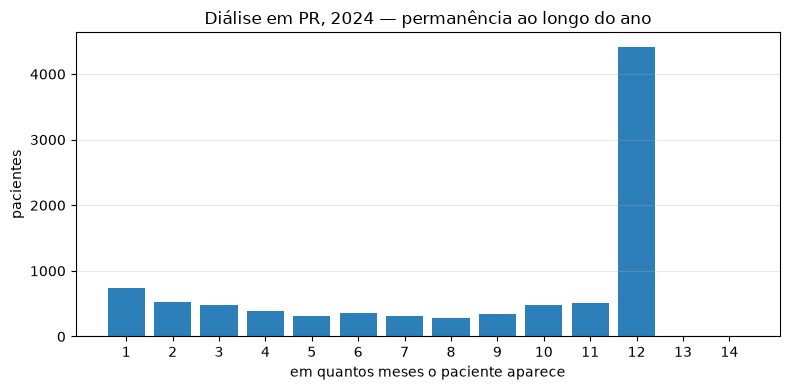

4,430 pacientes (48%) aparecem em 12 meses ou mais.
738 (8%) aparecem num mês só — entraram, saíram, mudaram de serviço ou morreram.


In [12]:
import matplotlib.pyplot as plt

permanencia = duckdb.sql(f"""
    WITH pessoas AS (
        SELECT AP_CNSPCN AS paciente, COUNT(DISTINCT AP_CMP) AS meses
        FROM read_parquet({arquivos!r}) GROUP BY 1
    )
    SELECT meses, COUNT(*) AS pacientes FROM pessoas GROUP BY 1 ORDER BY 1
""").df()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(permanencia["meses"].astype(str), permanencia["pacientes"],
       color="#2c7fb8")
ax.set_xlabel("em quantos meses o paciente aparece")
ax.set_ylabel("pacientes")
ax.set_title(f"Diálise em {UF}, {ANO} — permanência ao longo do ano")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

total = permanencia["pacientes"].sum()
ano_todo = permanencia.loc[permanencia["meses"] >= 12, "pacientes"].sum()
um_mes = permanencia.loc[permanencia["meses"] == 1, "pacientes"].sum()
print(f"{ano_todo:,} pacientes ({100*ano_todo/total:.0f}%) aparecem em 12 meses ou mais.")
print(f"{um_mes:,} ({100*um_mes/total:.0f}%) aparecem num mês só — entraram, saíram, "
      f"mudaram de serviço ou morreram.")

> Alguns pacientes aparecem em **mais de doze** competências: um arquivo mensal
> pode conter autorizações de competências anteriores. Se for calcular tempo em
> tratamento, conte competências distintas, não arquivos.

## Passo 9 — Os exames: primeiro o preenchimento, depois o valor

A base traz exames e sorologias. Antes de calcular qualquer média, meça **quanto
do campo está preenchido** — isso varia enormemente entre estados, e uma média
sobre 12% dos pacientes não descreve a população.

In [13]:
EXAMES = {"ATD_HB": "hemoglobina", "ATD_ALBUMI": "albumina",
          "ATD_FOSFOR": "fósforo", "ATD_PTH": "paratormônio",
          "ATD_KTVSEM": "Kt/V"}
CATEGORICOS = {"ATD_ACEVAS": "acesso vascular",
               "ATD_SITTRA": "situação quanto a transplante",
               "ATD_HIV": "sorologia HIV", "ATD_HCV": "sorologia hepatite C"}

linhas = []
for campo, nome in {**EXAMES, **CATEGORICOS}.items():
    d = duckdb.sql(f"""
        SELECT COUNT(*) AS total,
               SUM(CASE WHEN {campo} IS NULL
                         OR TRIM(CAST({campo} AS VARCHAR)) IN ('', '0', '0.00')
                    THEN 0 ELSE 1 END) AS preenchidos
        FROM read_parquet({arquivos!r})
    """).df()
    linhas.append({"campo": campo, "o que é": nome,
                   "preenchido %": round(100 * d.preenchidos[0] / d.total[0], 1)})
pd.DataFrame(linhas)

,campo,o que é,preenchido %
0,ATD_HB,hemoglobina,96.1
1,ATD_ALBUMI,albumina,90.4
2,ATD_FOSFOR,fósforo,95.9
3,ATD_PTH,paratormônio,88.8
4,ATD_KTVSEM,Kt/V,83.3
5,ATD_ACEVAS,acesso vascular,100.0
6,ATD_SITTRA,situação quanto a transplante,100.0
7,ATD_HIV,sorologia HIV,100.0
8,ATD_HCV,sorologia hepatite C,100.0


In [14]:
print("Os exames abaixo descrevem QUEM TEM O EXAME REGISTRADO, não todos:\n")
for campo, nome in EXAMES.items():
    d = duckdb.sql(f"""
        SELECT TRY_CAST({campo} AS DOUBLE) AS valor FROM read_parquet({arquivos!r})
        WHERE TRY_CAST({campo} AS DOUBLE) > 0
    """).df()
    if not len(d):
        print(f"{nome}: sem valores")
        continue
    print(f"  {nome:14s} n={len(d):>6,}  mediana {d.valor.median():>8.2f}  "
          f"(quartis {d.valor.quantile(.25):.2f} e {d.valor.quantile(.75):.2f})")

print("\nO acesso vascular e a situação de transplante vêm em código, e a PySUS")
print("não documenta nenhum dos dois. A distribuição real:")
for campo, nome in list(CATEGORICOS.items())[:2]:
    d = duckdb.sql(f"""
        SELECT CAST({campo} AS VARCHAR) AS codigo, COUNT(*) AS apacs
        FROM read_parquet({arquivos!r}) GROUP BY 1 ORDER BY 2 DESC
    """).df()
    d["%"] = (100 * d.apacs / d.apacs.sum()).round(1)
    print(f"\n  {nome} ({campo}):")
    print("   " + d.to_string(index=False).replace("\n", "\n   "))

Os exames abaixo descrevem QUEM TEM O EXAME REGISTRADO, não todos:
  hemoglobina    n=42,723  mediana    11.00  (quartis 10.00 e 12.50)
  albumina       n=43,388  mediana     4.00  (quartis 3.60 e 4.40)
  fósforo        n=41,892  mediana     5.40  (quartis 4.20 e 7.50)
  paratormônio   n=44,272  mediana   204.00  (quartis 83.00 e 426.00)
  Kt/V           n=32,224  mediana     1.40  (quartis 1.16 e 1.68)
O acesso vascular e a situação de transplante vêm em código, e a PySUS
não documenta nenhum dos dois. A distribuição real:
  acesso vascular (ATD_ACEVAS):
   codigo  apacs    %
        1  54964 67.0
        2  14707 17.9
        3  12359 15.1
  situação quanto a transplante (ATD_SITTRA):
   codigo  apacs    %
        2  36905 45.0
        1  26655 32.5
        4  12978 15.8
        3   5492  6.7


## O que este notebook não responde

- **Não é incidência de doença renal.** É a população autorizada a fazer
  diálise. Quem não chegou ao serviço não está aqui.
- **Não filtre pelo `group` da PySUS.** Ela junta prefixos diferentes sob o
  mesmo nome: `group="AM"` traz medicamentos **e** acompanhamento
  multiprofissional; `group="AB"` traz bariátrica **e** pós-bariátrica. Depois
  de concatenados, nada no DataFrame diz de qual arquivo veio cada linha. Use o
  prefixo do nome do arquivo, como o passo 1 faz.
- **Os códigos não estão documentados.** O de óbito foi identificado por
  cruzamento no passo 5; acesso vascular e transplante ficam como distribuição,
  sem rótulo inventado.
- **`AP_CIDPRI` vem vazio.** O campo de diagnóstico existe e não tem conteúdo —
  um campo existir não significa que foi preenchido.
- **O preenchimento dos exames varia — entre estados e entre meses.** No ano
  inteiro do Paraná o Kt/V está preenchido em 83% das autorizações; olhando só
  janeiro de 2024, em 42%. No Acre, em janeiro, fica perto de 12%. É por isso
  que o passo 9 mede antes de calcular: refaça-o sempre que trocar o recorte.
- **O CNES não traz o nome do estabelecimento.** Dá para caracterizar (natureza
  jurídica, município, gestão), não para identificar.